In [101]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [102]:
df=pd.read_csv("Data/voice.csv")
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [103]:
df.dropna(subset=['meanfreq', 'median', 'meanfun', 'label'], inplace=True)
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [104]:
dummies = pd.get_dummies(df, columns=['label'])
dummies.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label_female,label_male
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,False,True
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,False,True
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,False,True
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,False,True
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,False,True


In [105]:
x_meanfreq = df['meanfreq'].values.reshape(-1,1)
x_meanfreq = x_meanfreq[:,0]
x_median = df['median'].values.reshape(-1,1)
x_median = x_median[:,0]
x_meanfun = df['meanfun'].values.reshape(-1,1)
x_meanfun = x_meanfun[:,0]
y = dummies['label_male'].astype(int).values

In [106]:
print(np.any(np.isnan(y)))
print(np.any(np.isnan(x_meanfun)))
print(np.any(np.isnan(x_median)))
print(np.any(np.isnan(x_meanfreq)))

False
False
False
False


# Meanfreq
## Plot

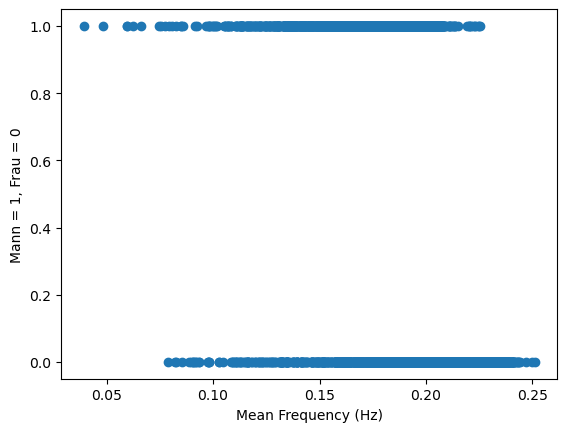

In [107]:
plt.plot(x_meanfreq, y, 'o')
plt.xlabel('Mean Frequency (Hz)')
plt.ylabel('Mann = 1, Frau = 0')
plt.show()

## Train_Test

In [108]:
X_Meanfreq_train, X_Meanfreq_test, y_Meanfreq_train, y_Meanfreq_test = train_test_split(x_meanfreq.reshape(-1,1), y, test_size=0.25, random_state=0)

## Model

In [109]:
logreg_meanfreq = LogisticRegression(penalty=None)
logreg_meanfreq.fit(X_Meanfreq_train, y_Meanfreq_train)
y_Meanfreq_pred = logreg_meanfreq.predict(X_Meanfreq_test)
y_Meanfreq_pred2=logreg_meanfreq.predict_proba(X_Meanfreq_test)[:,1]

## Klassifikationsmatrix

In [110]:
cnf_matrix = metrics.confusion_matrix(y_Meanfreq_test, y_Meanfreq_pred)
tn, fp, fn, tp = cnf_matrix.ravel()
print(f"tn: {tn},fp: {fp},fn: {fn},tp:{tp}")
print(f"score: {logreg_meanfreq.score(X_Meanfreq_test, y_Meanfreq_test)}")

tn: 274,fp: 99,fn: 182,tp:237
score: 0.6452020202020202


## Prozentsatz der richtigen Klassifikation

In [111]:
genauigkeit_meanfreq = metrics.accuracy_score(y_Meanfreq_test, y_Meanfreq_pred)
print(f"Genauigkeit: {genauigkeit_meanfreq * 100:.2f}%")

Genauigkeit: 64.52%


# Median
## Plot

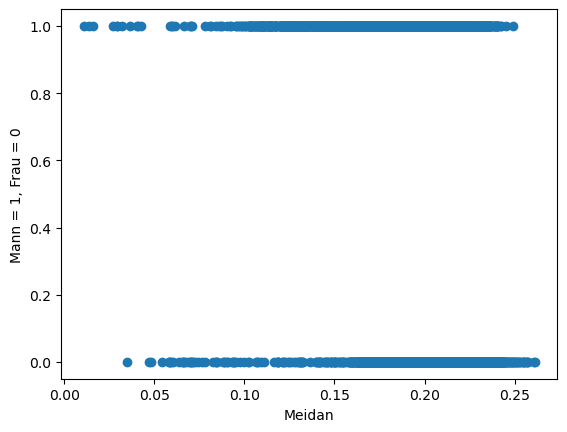

In [112]:
plt.plot(x_median, y, 'o')
plt.xlabel('Meidan')
plt.ylabel('Mann = 1, Frau = 0')
plt.show()

## Train_Test

In [113]:
X_Median_train, X_Median_test, y_Median_train, y_Median_test = train_test_split(x_median.reshape(-1,1), y, test_size=0.25, random_state=0)

## Model

In [114]:
logreg_median = LogisticRegression(penalty=None)
logreg_median.fit(X_Median_train, y_Median_train)
y_Median_pred = logreg_median.predict(X_Median_test)
y_Median_pred2=logreg_median.predict_proba(X_Median_test)[:,1]

## Klassifikationsmatrix

In [115]:
cnf_matrix = metrics.confusion_matrix(y_Median_test, y_Median_pred)
tn, fp, fn, tp = cnf_matrix.ravel()
print(f"tn: {tn},fp: {fp},fn: {fn},tp:{tp}")
print(f"score: {logreg_median.score(X_Median_test, y_Median_test)}")

tn: 278,fp: 95,fn: 185,tp:234
score: 0.6464646464646465


## Prozentsatz der richtigen Klassifikation

In [116]:
genauigkeit_median = metrics.accuracy_score(y_Median_test, y_Median_pred)
print(f"Genauigkeit: {genauigkeit_median * 100:.2f}%")

Genauigkeit: 64.65%


# Plot
## Meanfun

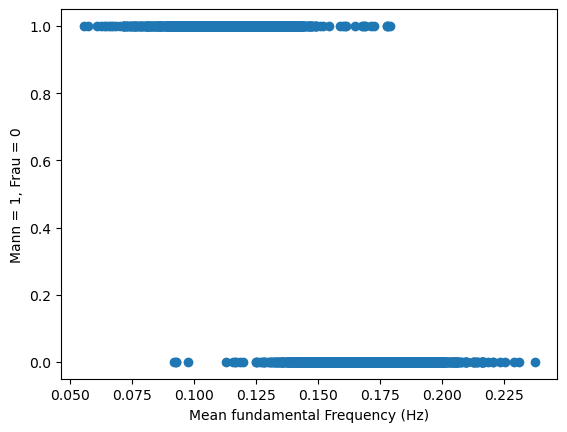

In [117]:
plt.plot(x_meanfun, y, 'o')
plt.xlabel('Mean fundamental Frequency (Hz)')
plt.ylabel('Mann = 1, Frau = 0')
plt.show()

## Train_Test

In [118]:
X_Meanfun_train, X_Meanfun_test, y_Meanfun_train, y_Meanfun_test = train_test_split(x_meanfun.reshape(-1,1), y, test_size=0.25, random_state=0)

## Model

In [119]:
logreg_meanfun = LogisticRegression(penalty=None)
logreg_meanfun.fit(X_Meanfun_train, y_Meanfun_train)
y_Meanfun_pred = logreg_meanfun.predict(X_Meanfun_test)
y_Meanfun_pred2=logreg_meanfun.predict_proba(X_Meanfun_test)[:,1]

## Klassifikationsmatrix

In [120]:
cnf_matrix = metrics.confusion_matrix(y_Meanfun_test, y_Meanfun_pred)
tn, fp, fn, tp = cnf_matrix.ravel()
print(f"tn: {tn},fp: {fp},fn: {fn},tp:{tp}")
print(f"score: {logreg_meanfreq.score(X_Meanfun_test, y_Meanfun_test)}")

tn: 352,fp: 21,fn: 14,tp:405
score: 0.6742424242424242


## Prozentsatz der richtigen Klassifikation

In [121]:
genauigkeit_meanfun = metrics.accuracy_score(y_Meanfun_test, y_Meanfun_pred)
print(f"Genauigkeit: {genauigkeit_meanfun * 100:.2f}%")

Genauigkeit: 95.58%


# Genaugikeiten zusammen

In [122]:
print(f"Genauigkeit Meanfreq: {genauigkeit_meanfreq * 100:.2f}%")
print(f"Genauigkeit Median: {genauigkeit_median * 100:.2f}%")
print(f"Genauigkeit Meanfun: {genauigkeit_meanfun * 100:.2f}%")

Genauigkeit Meanfreq: 64.52%
Genauigkeit Median: 64.65%
Genauigkeit Meanfun: 95.58%
